<a href="https://colab.research.google.com/github/MariaMinottaZ/university-predicting-project/blob/main/students-dropout-academic-success-predictive-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Limpieza dataset PEC1**

##Cargar datos

**Cargar datos desde drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


## Gráficos e interpretación


**Importar librerías y cargar data set**

In [ ]:
# coleccion de funciones que permite que matplotlib trabaja como MATLAB
import matplotlib.pyplot as plot
#data visualization library
import seaborn as sns
import numpy as np
import pandas as pd
# contiene funciones que pueden crear figuras completas a la vez
import plotly.express as px
import matplotlib.pyplot as plt
# biblioteca de visualización en Python para gráficos 2D de arreglos.
import matplotlib.ticker as mtick

#Particionamiento
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

#Balanceo
from collections import Counter

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from pylab import rcParams
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTETomek
from imblearn.ensemble import BalancedBaggingClassifier

#Se carga el dataset en el dataframe
df = pd.read_csv('/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/data.csv', delimiter=';')




**Función para números en diagramas de barras**

In [ ]:
def ponerNumerosBarra (ax):
  for bar in ax.patches:
        height = bar.get_height()
        width = bar.get_width()
        x = bar.get_x()
        y = bar.get_y()

        label_text = height
        label_x = x + width / 2
        label_y = y + height / 2


        ax.text(label_x, label_y, '{:,.1f}'.format(label_text), ha='center',
                va='center')



**Diagrama de barras Genero - Clase**

En esta gráfica se divide la población entre hombres y mujeres. Se diferencia la clase Dropout, Enrolled y Graduate (Desertado, Matriculado, Graduado)

De las 2868 mujeres, el 57% se han graduado, 16% están matriculadas y  25% han desertado.

De los 1556 hombres, el 35% se han graduado, 19% están matriculados y 45% han desertado.

Por tanto, el índice de deserción en mujeres es mucho menor.



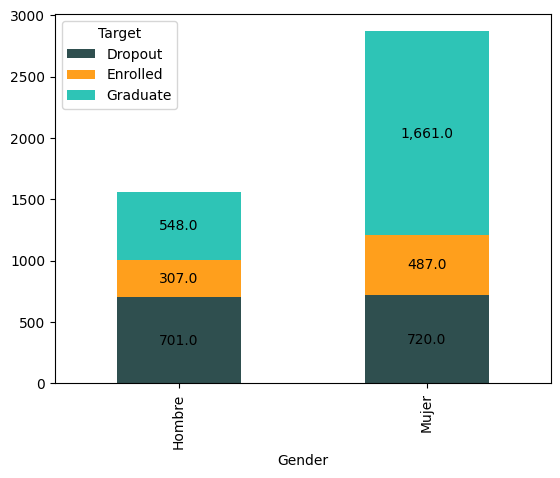

In [ ]:
gender_names = {
   0: "Mujer",
   1: "Hombre"
}

columna_genero = df.groupby([df['Gender'].map(gender_names), 'Target']).size().unstack().plot(kind='bar', stacked=True, color=["darkslategray", "#ff9f1c", "#2ec4b6"])

ponerNumerosBarra(columna_genero)
plt.show()

**Diagrama de barras Cursos-Clase**

En esta gráfica se divide la población en los diferentes cursos que han tomado. Se diferencia la clase Dropout, Enrolled y Graduate (Desertado, Matriculado, Graduado).


Se puede observar que los cursos con mayor índices de deserción en relación con el total de estudiantes son Biofuel Production Technologies, Equinculture e Informatics Engineering, los que tienen más proporción de graduados son Nursing, Social Service, Journalism and Communication y Veterinary Nursing, de los cuales 50% o más de se suelen graduar.



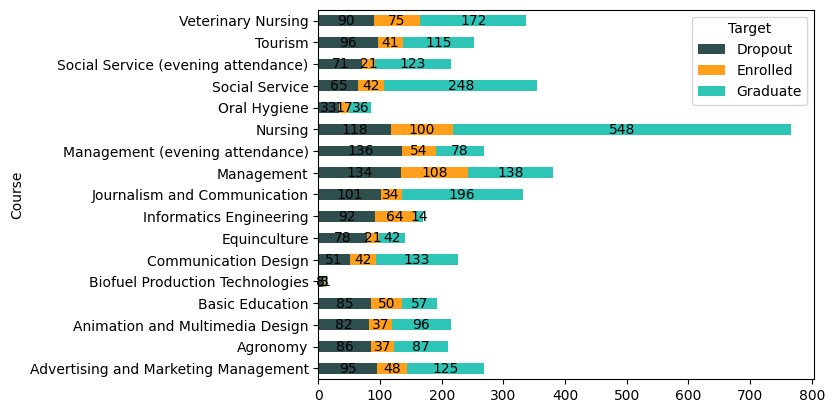

Curso: Biofuel Production Technologies, Desertores: 8, Porcentaje: 66.67%
Curso: Animation and Multimedia Design, Desertores: 82, Porcentaje: 38.14%
Curso: Social Service (evening attendance), Desertores: 71, Porcentaje: 33.02%
Curso: Agronomy, Desertores: 86, Porcentaje: 40.95%
Curso: Communication Design, Desertores: 51, Porcentaje: 22.57%
Curso: Veterinary Nursing, Desertores: 90, Porcentaje: 26.71%
Curso: Informatics Engineering, Desertores: 92, Porcentaje: 54.12%
Curso: Equinculture, Desertores: 78, Porcentaje: 55.32%
Curso: Management, Desertores: 134, Porcentaje: 35.26%
Curso: Social Service, Desertores: 65, Porcentaje: 18.31%
Curso: Tourism, Desertores: 96, Porcentaje: 38.10%
Curso: Nursing, Desertores: 118, Porcentaje: 15.40%
Curso: Oral Hygiene, Desertores: 33, Porcentaje: 38.37%
Curso: Advertising and Marketing Management, Desertores: 95, Porcentaje: 35.45%
Curso: Journalism and Communication, Desertores: 101, Porcentaje: 30.51%
Curso: Basic Education, Desertores: 85, Porcen

In [ ]:
#Mapeo del código al curso

course_names = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)'
}

def ponerNumerosBarra2(ax):
    for p in ax.patches:
        width = p.get_width()    # Obtener el ancho de cada barra
        height = p.get_height()  # Obtener la altura de cada barra
        x, y = p.get_xy()        # Obtener la posición de cada barra
        if width > 0:            # Solo mostrar si el valor es mayor a cero
            ax.text(x + width / 2, y + height / 2, f'{int(width)}', ha='center', va='center')

# Columna de curso
columna_course = df.groupby([df['Course'].map(course_names), 'Target']).size().unstack().plot(kind='barh', stacked=True, color=["darkslategray", "#ff9f1c", "#2ec4b6"])

# Mostrar los números en las barras
ponerNumerosBarra2(columna_course)

# Mostrar el gráfico

plt.show()

# Filtrar estudiantes que desertaron
dropouts_df = df[df['Target'] == 'Dropout']

# Contar desertores por curso
dropouts_count = dropouts_df.groupby('Course').size()

# Contar el total de estudiantes por curso
total_students_count = df.groupby('Course').size()

# Calcular el porcentaje de desertores por curso
dropouts_percentage = (dropouts_count / total_students_count * 100).fillna(0)

# Imprimir resultados de manera bonita
for course, count in dropouts_count.items():
    course_name = course_names.get(course)
    percentage = dropouts_percentage[course]
    print(f"Curso: {course_name}, Desertores: {count}, Porcentaje: {percentage:.2f}%")





**Barra ampliada de Biofuel Production Technologies:**

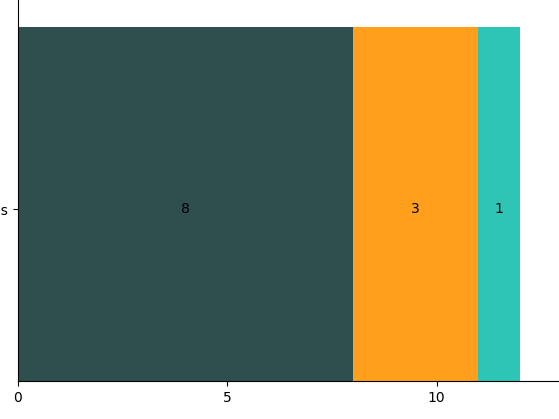

**Diagrama de barrás asistencia diurna/nocturna - clase**


En este diagrama de barras se relaciona si el estudiante estudia en horario diurno o nocturno con respecto a si está matriculado, graduado o desertó.
Se observa que de 3941 estudiantes que ven clase en jornada diurna, 1214 desertarón, con lo cual el 31% de estudiantes de jornada diurna desertó.
En jornada nocturna de 483 estudiantes, 207 desertaron, por lo tanto el porcentaje es mayor, siendo este de un 43%. Se podrían hacer una investigación para profundizar en la causa de que haya mas deserción en horario nocturno y plantear estrategías para reducir la discrepancia entre los dos horarios.

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


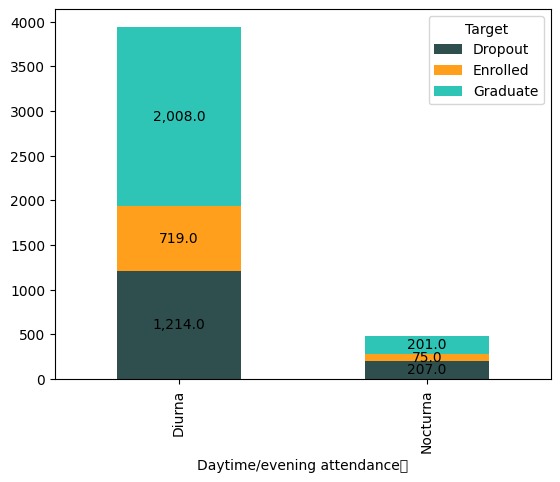

In [ ]:
attendance_names = {
   0: "Nocturna",
   1: "Diurna"
}

df.describe()

columna_genero = df.groupby([df['Daytime/evening attendance\t'].map(attendance_names), 'Target']).size().unstack().plot(kind='bar', stacked=True, color=["darkslategray", "#ff9f1c", "#2ec4b6"])
ponerNumerosBarra(columna_genero)
plt.show()

**Diagrama de barras matrículas al día - clase**

En este diagrama se relaciona si el estudiante tiene el pago de matriculas al día o no en relación con si está matriculado, graduado o desertó.

De 3896 estudiantes que estan al día en matriculas, 964 desertaron, representando el 24,74% del total.

De 528 estudiantes que no estan al día en matriculas, 457 desertaron, representando el 86,55% del total.

Por lo cual el estar al día en pago de matriculas o no parece un factor muy relevante para determinar si un estudiante podría llegar a desertar.



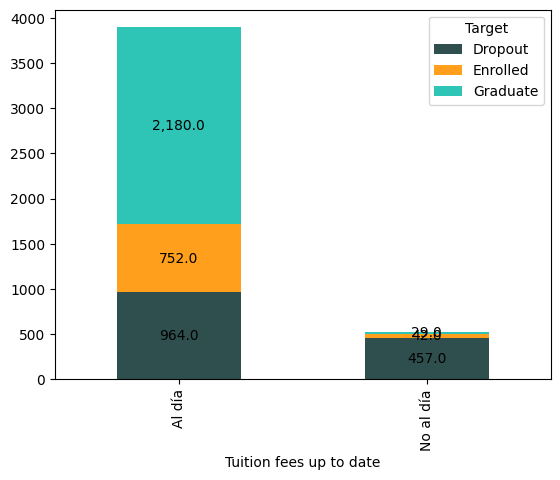

In [ ]:
tuitionfees_names = {
   0: "No al día",
   1: "Al día"
}

df.describe()

columna_genero = df.groupby([df['Tuition fees up to date'].map(tuitionfees_names), 'Target']).size().unstack().plot(kind='bar', stacked=True, color=["darkslategray", "#ff9f1c", "#2ec4b6"])
ponerNumerosBarra(columna_genero)
plt.show()

**Boxplot Edad - Clase**

En este diagrama se relaciona la edad de los estudiantes con la clase.

Se puede observar con respecto al rango intercuartilico que el 50% de los que desertaron tenian una edad entre 19 y 30 años aproximadamente, mientras que el 50% de los graduados y de los matriculados tienen un rango de edad entre 18 y 23 años, por lo tanto se podría plantear la hipotesis que entre mas edad, mayor es la tasa de deserción. También podemos notar que es atipico que alguien de mas de 25 años se gradue y que alguien de mas de 29 años se matricule.

Todos los boxplot tienen asimetría a la derecha, por lo cual se puede inferir que a poca edad hay más concentración de gente y que a más edad los datos están más dispersos.




In [ ]:
#Box plot "Edad en la que se matriculó" en relación con la clase
px.box(df, x='Target', y='Age at enrollment', title='Boxplot Target-Age at enrollment', color='Target', color_discrete_sequence=["darkslategray", "#2ec4b6", "#ff9f1c"])

**Boxplot notas primer semestre - clase**

En este diagrama se relaciona el promedio de notas del primer semestre (0-20) con la clase.
Teniendo en cuenta que se analiza un dataset de una universidad de Portugal, donde las notas van de 0 a 20 de la siguiente forma:


*   0-9,4: **Insuficiente (No aprobado)**
*   9,5-13,4: **Suficiente (Aprobado)**
*   13,5-15,4: Bueno
*   15,5-17,4: Muy bueno
*   17,5-20: Excelente

En relación con los estudiantes matriculados o graduados podemos ver que sus promedios de notas siempre van de 10 para adelante, por lo tanto, salvo datos atipicos, los matriculados o graduados tuvieron un buen desempeño academico en el primer semestre.

Se puede observar que en relación con los estudiantes que desertaron, el 25% tiene un promedio de nota de 0 en el primer semestre.

Se muestra también que la nota de la clase "matriculados" tienen una asimetría a la derecha, lo cual muestra que hay una gran concentración de notas bajas y las notas que son más altas suelen dispersarse. La clase "graduados" tiende a ser una distribución normal de 12.1 a 13.8. Sin embargo la clase "desertados" tiene asimetría a la izquierda, con el 25% o más con un promedio de nota de 0.

In [ ]:
#Box plot "Notas de primer semestre" en relación con la clase
px.box(df, x='Target', y='Curricular units 1st sem (grade)', color='Target', title='Boxplot Target-Curricular units 1st sem (grade)', color_discrete_sequence=["darkslategray", "#2ec4b6", "#ff9f1c"])

**Boxplot notas segundo semestre - clase**

En este diagrama se relaciona el promedio de notas del segundo semestre (0-20) con la clase.
Teniendo en cuenta que se analiza un dataset de una universidad de Portugal, donde las notas van de 0 a 20 de la siguiente forma:


*   0-9,4: **Insuficiente (No aprobado)**
*   9,5-13,4: **Suficiente (Aprobado)**
*   13,5-15,4: Bueno
*   15,5-17,4: Muy bueno
*   17,5-20: Excelente

Se puede observar en relación con los estudiantes que desertaron, que el 50% o más tienen un promedio de nota de 0 en el segundo semestre, el siguiente 25% tienen un promedio de nota entre 0 y 11,75 (aproximadamente) y  el 25% restante que desertaron tienen más de 11,75 (aproximadamente) de nota.

En relación con matriculados y graduados salvo casos atipicos todos tuvieron nota mayor o igual a la aprobatoria, por lo tanto tuvieron un buen desempeño academico.  

La distribución de la clase "graduados" y los "matriculados" vuelve a tender a ser normal y asimétrica a la derecha, respectivamente. Sin embargo, la distribución de "desertores" se vuelve aimétrica a la derecha, hay una gran concentración de personas que han sacado 0.


In [ ]:
#Box plot "Notas de segundo semestre" en relación con la clase
px.box(df, x='Target', y='Curricular units 2nd sem (grade)', title='Boxplot Target-Curricular units 2st sem (grade)', color='Target', color_discrete_sequence=["darkslategray", "#2ec4b6", "#ff9f1c"])

**Matriz de correlación**

La matriz de correlación ayuda a entender que variables tiene una relación lineal alta entre sí, de este modo se puede ver que variables se pueden borrar por estar altamente relacionadas (por encima de 0,7), ya que en un futuro se podría predecir el dato de la variable borrada a partir de la que se quedó para el modelo.



In [ ]:
import plotly.figure_factory as ff
import numpy as np
import pandas as pd

correlation = df.corr(numeric_only=True).values

names = list(df.corr(numeric_only=True).columns.values)

inverted_corr = correlation[::-1]

final_corr = inverted_corr

formatted_corr = np.around(final_corr, 1).astype(str)

fig = ff.create_annotated_heatmap(
    z=final_corr,
    x=names,
    y=names[::-1],
    colorscale='YlGnBu',
    annotation_text=formatted_corr
)

fig.show()


##Limpieza de datos


**Descripción de las variables**


In [ ]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


**Columnas nulas**

Revisión de columnas con datos nulos. Todas las columnas están completas

In [ ]:
df.isnull().any()

,0
Marital status,False
Application mode,False
Application order,False
Course,False
Daytime/evening attendance\t,False
Previous qualification,False
Previous qualification (grade),False
Nacionality,False
Mother's qualification,False
Father's qualification,False


Con el propósito de limpiar el dataframe se creará una copia del original

In [ ]:
dflimpio = df.copy()

Se codifica la clase para poder ver correlación

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Inicializa el codificador de etiquetas
label_encoder = LabelEncoder()

# Ajusta el codificador y transforma los datos
dflimpio['Target_encoded'] = label_encoder.fit_transform(dflimpio['Target'])

# Mostrar las primeras filas para verificar la conversión
print(dflimpio[['Target', 'Target_encoded']].head())

     Target  Target_encoded
0   Dropout               0
1  Graduate               2
2   Dropout               0
3  Graduate               2
4  Graduate               2


**Se eligirá una de cada dos columnas altamente correlacionadas para la creación del modelo**

Se eliminarán:
Father's occupation, por similitud a Mother's occupation, con una correlación de 0,91 aproximadamente.

Nacionality, por similitud a international, con una correlación de 0,8 aproximadamente.

Curricular units 2nd sem (approved), Curricular units 1st sem (approved) y Curricular units 1st sem (grade) por similiud a Curricular units 2nd sem (grade). Se prioriza elegir Curricular units 2nd sem (grade) porque los datos que muestra se encuentran más segmentados.

Curricular units 1st sem (evaluations), por similitud a Curricular units 2nd sem (evaluations)

Curricular units 1st sem (enrolled)  y Curricular units 2nd sem (credited) por similitud a Curricular units 2nd sem (enrolled)


In [ ]:
import plotly.figure_factory as ff
import numpy as np
import pandas as pd

dflimpio.drop(columns=["Father's occupation", 'Nacionality', 'Curricular units 2nd sem (approved)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (enrolled)', 'Curricular units 2nd sem (credited)'],  inplace=True)

correlation = dflimpio.corr(numeric_only=True).values

names = list(dflimpio.corr(numeric_only=True).columns.values)

inverted_corr = correlation[::-1]

final_corr = inverted_corr

formatted_corr = np.around(final_corr, 1).astype(str)

fig = ff.create_annotated_heatmap(
    z=final_corr,
    x=names,
    y=names[::-1],
    colorscale='YlGnBu',
    annotation_text=formatted_corr
)

fig.show()



**Eliminación de datos atípicos**



Eliminación de datos atípicos de la edad en relación con la clase

In [ ]:
import pandas as pd

columna_clase = 'Target'
columna_objetivo = 'Age at enrollment'

def reemplazar_outliers_por_media(grupo):
    Q1 = grupo.quantile(0.25)
    Q3 = grupo.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    datos_no_atipicos = grupo[(grupo >= limite_inferior) & (grupo <= limite_superior)]
    media_grupo = datos_no_atipicos.mean()

    return grupo.mask((grupo < limite_inferior) | (grupo > limite_superior), media_grupo)

dflimpio[columna_objetivo] = df.groupby(columna_clase)[columna_objetivo].transform(reemplazar_outliers_por_media)


Boxplot para evidenciar la eliminación de los datos átipicos

In [ ]:

px.box(dflimpio, x='Target', y='Age at enrollment', title='Boxplot Target-Age at enrollment', color='Target', color_discrete_sequence=["darkslategray", "#2ec4b6", "#ff9f1c"])

Eliminación de datos atipicos de las notas
 unidades curriculares de 2nd sem en relación con la clase

In [ ]:
import pandas as pd

columna_clase = 'Target'
columna_objetivo = 'Curricular units 2nd sem (grade)'

def reemplazar_outliers_por_media(grupo):
    Q1 = grupo.quantile(0.25)
    Q3 = grupo.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    datos_no_atipicos = grupo[(grupo >= limite_inferior) & (grupo <= limite_superior)]
    media_grupo = datos_no_atipicos.mean()

    return grupo.mask((grupo < limite_inferior) | (grupo > limite_superior), media_grupo)


dflimpio[columna_objetivo] = df.groupby(columna_clase)[columna_objetivo].transform(reemplazar_outliers_por_media)

Boxplot para evidenciar la eliminación de los datos átipicos

In [ ]:

px.box(dflimpio, x='Target', y='Curricular units 2nd sem (grade)', title='Boxplot Target-Curricular units 2nd sem (grade)', color='Target', color_discrete_sequence=["darkslategray", "#2ec4b6", "#ff9f1c"])

Eliminación de datos atipicos unidades curriculares inscritas en el segundo semestre en relación con la clase

In [ ]:
import pandas as pd

columna_clase = 'Target'
columna_objetivo = 'Curricular units 2nd sem (enrolled)'

def reemplazar_outliers_por_media(grupo):
    Q1 = grupo.quantile(0.25)
    Q3 = grupo.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    datos_no_atipicos = grupo[(grupo >= limite_inferior) & (grupo <= limite_superior)]
    media_grupo = datos_no_atipicos.mean()

    return grupo.mask((grupo < limite_inferior) | (grupo > limite_superior), media_grupo)


dflimpio[columna_objetivo] = df.groupby(columna_clase)[columna_objetivo].transform(reemplazar_outliers_por_media)

Boxplot para evidenciar la eliminación de los datos átipicos

In [ ]:

px.box(dflimpio, x='Target', y='Curricular units 2nd sem (enrolled)', title='Boxplot Curricular units 2nd sem (enrolled)', color='Target', color_discrete_sequence=["darkslategray", "#2ec4b6", "#ff9f1c"])

Eliminación de datos atipicos de las unidades curriculares de segundo semestre (evaluaciones) en relación con la clase

In [ ]:
import pandas as pd

columna_clase = 'Target'
columna_objetivo = 'Curricular units 2nd sem (evaluations)'

def reemplazar_outliers_por_media(grupo):
    Q1 = grupo.quantile(0.25)
    Q3 = grupo.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    datos_no_atipicos = grupo[(grupo >= limite_inferior) & (grupo <= limite_superior)]
    media_grupo = datos_no_atipicos.mean()

    return grupo.mask((grupo < limite_inferior) | (grupo > limite_superior), media_grupo)


dflimpio[columna_objetivo] = df.groupby(columna_clase)[columna_objetivo].transform(reemplazar_outliers_por_media)

Boxplot para evidenciar la eliminación de los datos átipicos

In [ ]:

px.box(dflimpio, x='Target', y='Curricular units 2nd sem (evaluations)', title='Boxplot Curricular units 2nd sem (evaluations)', color='Target', color_discrete_sequence=["darkslategray", "#2ec4b6", "#ff9f1c"])

Eliminación de datos atipicos de la nota de admisión
en relación con la clase

In [ ]:
import pandas as pd

columna_clase = 'Target'
columna_objetivo = 'Admission grade'

def reemplazar_outliers_por_media(grupo):
    Q1 = grupo.quantile(0.25)
    Q3 = grupo.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    datos_no_atipicos = grupo[(grupo >= limite_inferior) & (grupo <= limite_superior)]
    media_grupo = datos_no_atipicos.mean()

    return grupo.mask((grupo < limite_inferior) | (grupo > limite_superior), media_grupo)


dflimpio[columna_objetivo] = df.groupby(columna_clase)[columna_objetivo].transform(reemplazar_outliers_por_media)

Boxplot para evidenciar la eliminación de los datos átipicos

In [ ]:
px.box(dflimpio, x='Target', y='Admission grade', title='Boxplot Admission grade', color='Target', color_discrete_sequence=["darkslategray", "#2ec4b6", "#ff9f1c"])

Eliminación de datos atipicos de la nota previa de calificación en relación con la clase

In [ ]:
import pandas as pd

columna_clase = 'Target'
columna_objetivo = 'Previous qualification (grade)'

def reemplazar_outliers_por_media(grupo):
    Q1 = grupo.quantile(0.25)
    Q3 = grupo.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    datos_no_atipicos = grupo[(grupo >= limite_inferior) & (grupo <= limite_superior)]
    media_grupo = datos_no_atipicos.mean()

    return grupo.mask((grupo < limite_inferior) | (grupo > limite_superior), media_grupo)


dflimpio[columna_objetivo] = df.groupby(columna_clase)[columna_objetivo].transform(reemplazar_outliers_por_media)

Boxplot para evidenciar la eliminación de los datos átipicos

In [ ]:
px.box(dflimpio, x='Target', y='Previous qualification (grade)', title='Boxplot Previous qualification (grade)', color='Target', color_discrete_sequence=["darkslategray", "#2ec4b6", "#ff9f1c"])

Eliminación de datos átipicos del orden de aplicación en relación con la clase

In [ ]:
import pandas as pd

columna_clase = 'Target'
columna_objetivo = 'Application order'

def reemplazar_outliers_por_media(grupo):
    Q1 = grupo.quantile(0.25)
    Q3 = grupo.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    datos_no_atipicos = grupo[(grupo >= limite_inferior) & (grupo <= limite_superior)]
    media_grupo = datos_no_atipicos.mean()

    return grupo.mask((grupo < limite_inferior) | (grupo > limite_superior), media_grupo)


dflimpio[columna_objetivo] = df.groupby(columna_clase)[columna_objetivo].transform(reemplazar_outliers_por_media)

Boxplot para evidenciar la eliminación de los datos atipicos

In [ ]:
px.box(dflimpio, x='Target', y='Application order', title='Boxplot Application order', color='Target', color_discrete_sequence=["darkslategray", "#2ec4b6", "#ff9f1c"])

##Unificación de clases enrolled y graduated


**Distribución de la clasificación**

Esta gráfica representa el número de personas que se encuentran por la categoría de target. Se puede dividir en Dropout, Enrolled y Graduate (Desertado, Matriculado, Graduado). Se puede observar que los datos están desbalanceados, teniendo solo 794 personas en la clase minoritaria de “Matriculado” y 2209 personas en la clase mayoritaria de “Graduado”. Por lo tanto es importante usar una técnica de submuestreo o sobremuestreo con tal de evitar un sesgo en las predicciones del modelo.


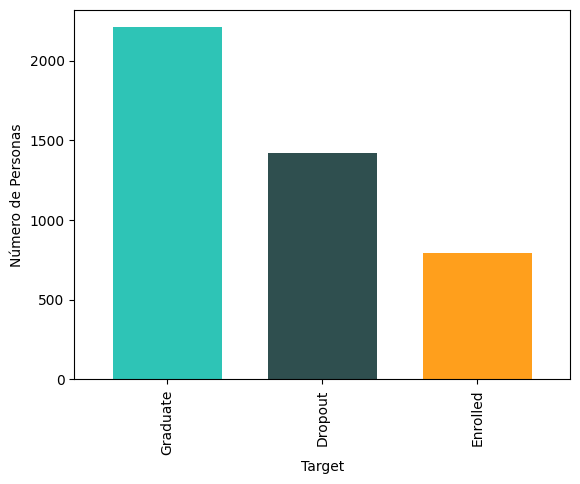

In [ ]:
conteo_target = df['Target'].value_counts().reset_index()
conteo_target.columns = ['Target', 'Count']

ax = conteo_target.plot(kind='bar', x='Target', y='Count', width=0.7, legend=False, color=["#2ec4b6","darkslategray", "#ff9f1c"])

ax.set(xlabel='Target', ylabel='Número de Personas')

plt.show()

**Unificación de las clases**

Con el propósito de una mejor predicción al realizar un analisis binario de las clases se van a unificar las clases graduado y matriculado, ya que en nuestro contexto lo que nos interesa es saber si alguien desertó o no desertó y se puede observar en muchos de los gráficos anteriores que los matriculados y los graduados parecen estadisticamente similares.  

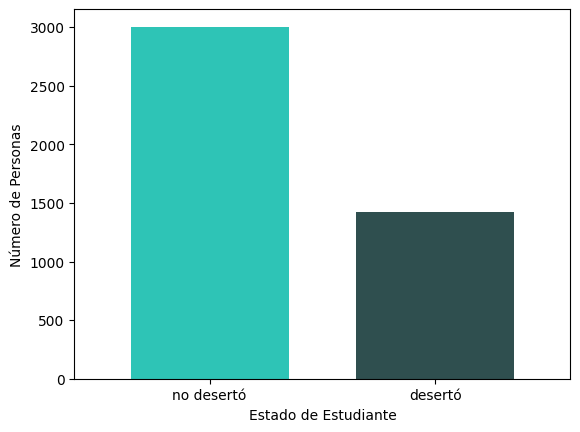

In [ ]:
import matplotlib.pyplot as plt

# Reemplazar 2 por 1 en el dataset
dflimpio['Target_encoded'] = dflimpio['Target_encoded'].replace(2, 1)

conteo_target = dflimpio['Target_encoded'].value_counts().reset_index()
conteo_target.columns = ['Target', 'Count']

ax = conteo_target.plot(kind='bar', x='Target', y='Count', width=0.7, legend=False, color=["#2ec4b6", "darkslategray", "#ff9f1c"])

ax.set_xticklabels(['no desertó', 'desertó'], rotation=0)

ax.set(xlabel='Estado de Estudiante', ylabel='Número de Personas')

# Mostrar el gráfico
plt.show()


##Particionamiento del DataSet

Con el proposito de particionar el dataset se debe primero eliminar la columna de target ( la que no está codificada ) de el dataset limpio, luego se usará train_test_split para particionar un 70% para entrenamiento y 30% para testeo.


In [ ]:

dflimpio.drop(columns='Target', inplace=True)

X = dflimpio.drop('Target_encoded', axis=1)
y = dflimpio['Target_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test

Se muestran los datos particionados

In [ ]:
X_train #Datos de entrenamiento del modelo sin la clase

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,...,International,Curricular units 1st sem (credited),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
1501,1,1,1.00000,9670,1,1,126.0,1,1,90,...,0,0,1,6.0,0.0,0.000000,0,10.8,1.4,1.74
2704,1,17,1.00000,9670,1,1,109.0,1,1,4,...,0,0,0,5.0,5.0,12.111264,0,7.6,2.6,0.32
4283,1,39,1.00000,9147,1,19,100.0,38,19,7,...,0,0,0,5.0,9.0,0.000000,0,10.8,1.4,1.74
1288,1,1,1.00000,9773,1,1,120.0,36,37,0,...,0,0,0,6.0,11.0,11.500000,0,7.6,2.6,0.32
137,1,1,1.00000,9773,1,1,153.0,1,1,141,...,0,0,0,6.0,6.0,14.833333,0,8.9,1.4,3.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,2,1,1.00000,8014,0,1,151.0,37,37,9,...,0,0,0,6.0,7.0,10.500000,0,10.8,1.4,1.74
2763,1,43,1.00000,8014,0,3,133.1,9,9,90,...,0,8,0,7.0,7.0,13.285714,0,7.6,2.6,0.32
905,1,1,3.00000,9500,1,1,114.0,1,1,5,...,0,0,0,8.0,8.0,12.550000,0,12.4,0.5,1.79
3980,1,17,1.34307,9238,1,1,117.0,1,38,4,...,0,0,0,6.0,6.0,13.333333,0,13.9,-0.3,0.79


In [ ]:
X_test

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,...,International,Curricular units 1st sem (credited),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
44,1,39,1.00000,9991,0,1,133.1,37,37,9,...,0,0,0,5.0,0.0,0.000000,0,16.2,0.3,-0.92
3411,1,17,1.34307,9500,1,1,129.0,38,37,9,...,0,0,0,8.0,8.0,12.454286,0,10.8,1.4,1.74
4212,1,17,2.00000,9773,1,1,125.0,1,1,4,...,0,0,0,6.0,6.0,14.666667,0,12.4,0.5,1.79
3037,1,1,1.00000,9670,1,1,126.0,1,1,9,...,0,0,0,6.0,9.0,13.000000,0,8.9,1.4,3.51
1672,1,44,1.00000,9130,1,39,130.0,3,1,4,...,0,1,0,6.0,10.0,12.000000,0,16.2,0.3,-0.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3455,1,1,1.00000,9238,1,1,145.0,19,1,6,...,0,0,0,6.0,6.0,13.166667,0,12.7,3.7,-1.70
3925,1,43,1.00000,9147,1,1,127.0,1,5,9,...,1,0,0,5.0,5.0,12.111264,0,15.5,2.8,-4.06
3823,1,44,1.00000,9130,1,39,130.0,38,19,9,...,0,2,0,6.0,8.0,13.500000,0,11.1,0.6,2.02
1396,1,1,1.00000,9130,1,1,133.1,1,1,3,...,0,0,0,6.0,10.0,13.000000,0,16.2,0.3,-0.92


## Balanceo del dataset


Primero se mostrará cuanto es el desbalance de clase, siendo 0 los desertores y 1 los matriculados o graduados

In [ ]:
y_train.value_counts()


,count
Target_encoded,
1,2081
0,1015


Ya que los matriculados o graduados son un poco mas del doble respecto a los desertores se eligirá SMOTENN como método para balancear las dos clases, ya que no hay un desbalance muy exagerado.

In [ ]:
from imblearn.combine import SMOTEENN
smk = SMOTEENN()
X_train_res, y_train_res = smk.fit_resample(X_train, y_train)
X_test_res, y_test_res = smk.fit_resample(X_test,y_test)

print ("Distribution before resampling {}".format(Counter(y_train)))
print ("Distribution after resampling {}".format(Counter(y_train_res)))
print ("Distribution before resampling {}".format(Counter(y_test)))
print ("Distribution after resampling {}".format(Counter(y_test_res)))



Distribution before resampling Counter({1: 2081, 0: 1015})
Distribution after resampling Counter({0: 1344, 1: 1176})
Distribution before resampling Counter({1: 922, 0: 406})
Distribution after resampling Counter({0: 621, 1: 496})


## Normalización, tipificación y codificación de datos

Al normalizar se separaran variables categorícas de variables numéricas antes de hacer el proceso ya que las númericas se normalizarán y las categóricas se codificarán, la mayoría de variables categóricas no se codificaron ya que ya estaban codificadas con anterioridad.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

mapeo_cursos = {
    33: 1,
    9130: 2,
    9119: 3,
    9991: 4,
    9853: 5,
    9003: 6,
    9556: 7,
    171: 8,
    9254: 9,
    9670: 10,
    9147: 11,
    8014: 12,
    9773: 13,
    9085: 14,
    9070: 15,
    9238: 16,
    9500: 17
}

# Mapeo o codificación del curso
X_train_res = X_train_res.replace({'Course': mapeo_cursos})
X_test_res = X_test_res.replace({'Course': mapeo_cursos})

# Corregir nombre de columna
X_train_res = X_train_res.rename(columns={'Daytime/evening attendance\t': 'Daytime/evening attendance'})
X_test_res = X_test_res.rename(columns={'Daytime/evening attendance\t': 'Daytime/evening attendance'})

# Variables categóricas
categorical_cols = ['Marital status', 'Daytime/evening attendance', 'Course',
                    'Previous qualification', "Mother's qualification", "Father's qualification",
                    "Mother's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Application mode',
                    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

# Variables numéricas
numeric_cols = ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
                'Curricular units 1st sem (credited)', 'Curricular units 1st sem (without evaluations)',
                'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
                'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
                'Unemployment rate', 'Inflation rate', 'GDP']

# Separar las variables numéricas de los datasets
X_train_numeric = X_train_res[numeric_cols]
X_test_numeric = X_test_res[numeric_cols]

# Estandarización de variables numéricas con Z-score
scaler = StandardScaler()
X_train_numeric_standardized = scaler.fit_transform(X_train_numeric)
X_test_numeric_standardized = scaler.transform(X_test_numeric)

# Convertir las variables estandarizadas a DataFrame
X_train_numeric_standardized = pd.DataFrame(X_train_numeric_standardized, columns=numeric_cols)
X_test_numeric_standardized = pd.DataFrame(X_test_numeric_standardized, columns=numeric_cols)

# Combinar las variables numéricas estandarizadas con las variables categóricas originales
X_train_final = pd.concat([X_train_numeric_standardized, X_train_res[categorical_cols].reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_numeric_standardized, X_test_res[categorical_cols].reset_index(drop=True)], axis=1)

X_train_final.shape
X_test_final.shape



(1117, 28)

##Dataset reducido con los atributos mas importantes



Se construirá un segundo dataset con los atributos que mas peso tienen para hacer otro modelo entrenado con estos, de este modo se podrá comparar cual modelo es mas preciso.

In [ ]:
X_train_final.columns

Index(['Application order', 'Previous qualification (grade)',
       'Admission grade', 'Age at enrollment',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Marital status', 'Daytime/evening attendance',
       'Course', 'Previous qualification', 'Mother's qualification',
       'Father's qualification', 'Mother's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Application mode',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'International'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif


k = 10

# Crear el objeto SelectKBest
selector = SelectKBest(score_func=f_classif, k=k)

# Ajustar y transformar X_train_final
X_train_selected = selector.fit_transform(X_train_final, y_train_res)

# Transformar X_test_final
X_test_selected = selector.transform(X_test_final)

# Obtener las características seleccionadas
selected_features = X_train_final.columns[selector.get_support()]

# Convertir a DataFrame si es necesario
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_features)

# Verificar las formas finales
print("X_train_selected shape:", X_train_selected_df.shape)
print("X_test_selected shape:", X_test_selected_df.shape)
print("Selected features:", selected_features)



X_train_selected shape: (2520, 10)
X_test_selected shape: (1117, 10)
Selected features: Index(['Previous qualification (grade)', 'Admission grade',
       'Age at enrollment', 'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (grade)', 'Displaced', 'Application mode',
       'Tuition fees up to date', 'Scholarship holder'],
      dtype='object')


##Construcción del modelo


Se construirán dos modelos, uno con del dataset reducido y otro con el dataset normal.

**Dataset normal:**

In [ ]:

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Crear el modelo SVM
svm_model = SVC(kernel='linear')

# 2. Entrenar el modelo
svm_model.fit(X_train_final, y_train_res)

# 3. Realizar predicciones
y_pred = svm_model.predict(X_test_final)

# 4. Evaluar el modelo
accuracy = accuracy_score(y_test_res, y_pred)
conf_matrix = confusion_matrix(y_test_res, y_pred)
class_report = classification_report(y_test_res, y_pred)

# Imprimir los resultados
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Accuracy: 0.9498657117278424
Confusion Matrix:
 [[584  37]
 [ 19 477]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95       621
           1       0.93      0.96      0.94       496

    accuracy                           0.95      1117
   macro avg       0.95      0.95      0.95      1117
weighted avg       0.95      0.95      0.95      1117



**Dataset reducido:**

In [ ]:

from sklearn.svm import SVC  # Importar el clasificador SVM
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# 1. Crear el modelo SVM
svm_model = SVC(kernel='linear')

# 2. Entrenar el modelo
svm_model.fit(X_train_selected_df, y_train_res)

# 3. Realizar predicciones
y_pred = svm_model.predict(X_test_selected_df)

# 4. Evaluar el modelo
accuracy = accuracy_score(y_test_res, y_pred)
conf_matrix = confusion_matrix(y_test_res, y_pred)
class_report = classification_report(y_test_res, y_pred)

# Imprimir los resultados
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.9391226499552372
Confusion Matrix:
 [[571  50]
 [ 18 478]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.92      0.94       621
           1       0.91      0.96      0.93       496

    accuracy                           0.94      1117
   macro avg       0.94      0.94      0.94      1117
weighted avg       0.94      0.94      0.94      1117



## Hiperparametros

Se buscarán los mejores hiperparametros para aplicar al modelo.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['linear', 'rbf']
}

# Crear el modelo SVM
svm_model = SVC()

# Crear el objeto GridSearchCV
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid,
                           scoring='accuracy', cv=5, n_jobs=-1)

# Entrenar con los datos de entrenamiento
grid_search.fit(X_train_selected_df, y_train_res)

# Obtener los mejores parámetros
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Mejores parámetros:", best_params)
print("Mejor precisión en validación cruzada:", best_score)


Mejores parámetros: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Mejor precisión en validación cruzada: 0.9472222222222223


## Generación del modelo con hiperparametros y mejor dataset

Generamos el modelo con los hiperparametros identificados y el mejor dataset que tuvimos el cual fue el reducido.



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mejores parametros identificados
best_params = {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


svm_model = SVC(**best_params)

# 2. Entrenar el modelo
svm_model.fit(X_train_selected_df, y_train_res)

# 3. Realizar predicciones
y_pred = svm_model.predict(X_test_selected_df)

# 4. Evaluar el modelo
accuracy = accuracy_score(y_test_res, y_pred)
conf_matrix = confusion_matrix(y_test_res, y_pred)
class_report = classification_report(y_test_res, y_pred)

# Imprimir los resultados
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Accuracy: 0.9328558639212176
Confusion Matrix:
 [[572  49]
 [ 26 470]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       621
           1       0.91      0.95      0.93       496

    accuracy                           0.93      1117
   macro avg       0.93      0.93      0.93      1117
weighted avg       0.93      0.93      0.93      1117



# Exportar dataset final a un csv


In [ ]:

import pandas as pd
from google.colab import files

# Exportar los DataFrames a archivos CSV
X_train_final.to_csv('X_train_final.csv', index=False)
X_test_final.to_csv('X_test_final.csv', index=False)
y_train_res.to_csv('y_train_res.csv', index=False)
y_test_res.to_csv('y_test_res.csv', index=False)

# Descargar los archivos a tu computadora
X_train_final.to_csv('/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/X_train_final.csv', index=False)
X_test_final.to_csv('/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/X_test_final.csv', index=False)
y_train_res.to_csv('/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/y_train_res.csv', index=False)
y_test_res.to_csv('/content/drive/MyDrive/inteligenciaArtificial20242JuanDiegoCortesEdisonLargoMariaJoséMinotta/y_test_res.csv', index=False)
